# Get Sonoptix Images

In [36]:
import numpy as np, cv2
import matplotlib.pyplot as plt
from tools.tools import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Read Data

In [37]:
real_sonoptix_data = get_sonoptix_data("/root/stonefish_ros2_ws/sintef_dataset/2024-08-20_16-34-34_video.bag")
simulated_sonoptix_data = get_simulated_image_data(bag="/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_10_24-08_32_44", topic="/multibeam_sonar/image")

# Display Sonoptix Data

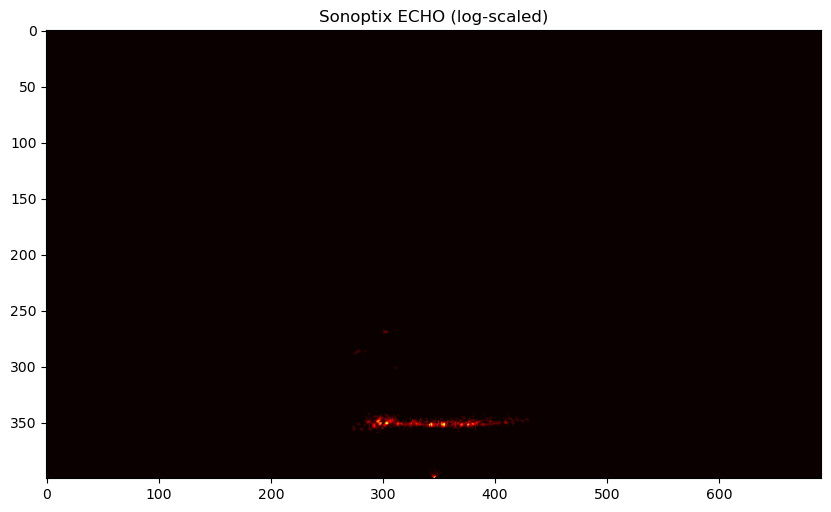

In [62]:
image = get_image_nearest_time(real_sonoptix_data, 40)

# Clip
image = image[:400, :]

# Map to polar
image = map_to_sector(image, fov_deg=120)

# Normalize intenisty values 0 to 255
image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)

# Log transform
# image = np.log(image + 1)

# Flip
image = np.flipud(image) 

plt.figure(figsize=(10, 10))
plt.title("Sonoptix ECHO (log-scaled)")
plt.imshow(image, cmap="hot")

# Plot ROS2 Simulated

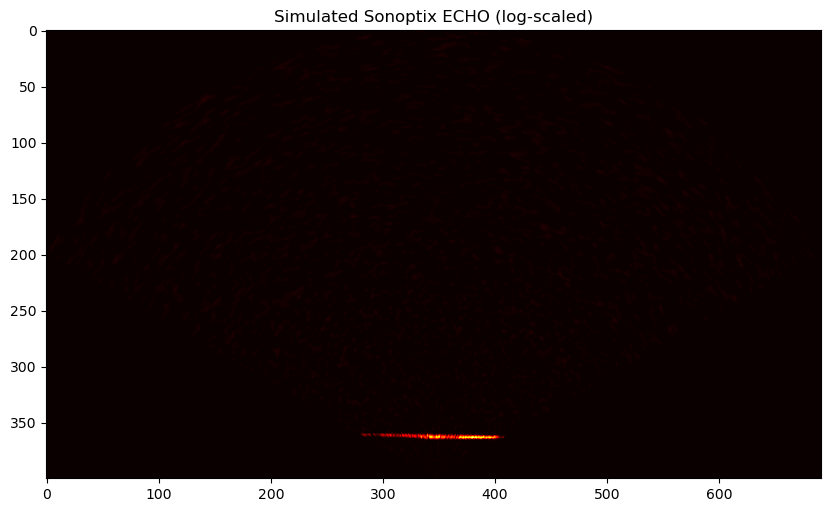

In [64]:
image = get_image_nearest_time(simulated_sonoptix_data, 10)

# Crop
image = image[(1024-400):, :]

# Map to sector
image = np.rot90(image, k=2)
image = map_to_sector(image, fov_deg=120)
image = np.rot90(image, k=2)


# Normalize intenisty values 0 to 255
image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)

image = np.fliplr(image)

# Log transform
# image = np.log(image + 1)

plt.figure(figsize=(10, 10))
plt.title("Simulated Sonoptix ECHO (log-scaled)")
plt.imshow(image, cmap="hot")

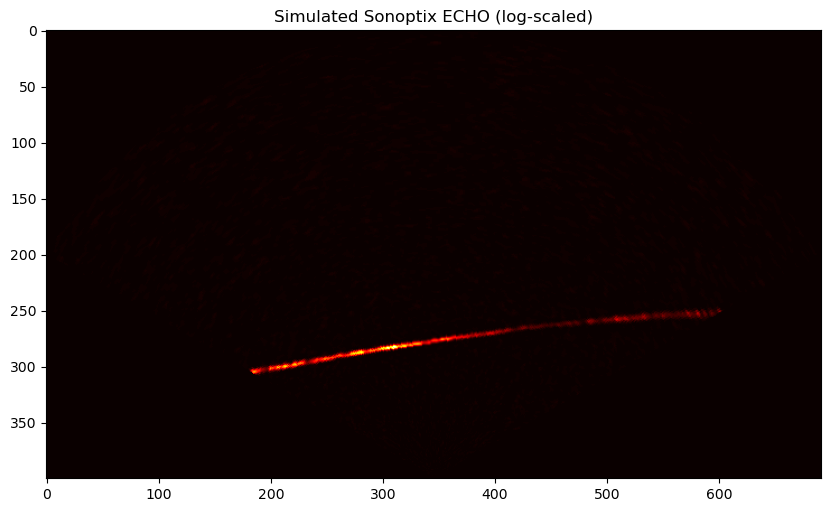

In [70]:
bag_path = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_10_30-10_24_05"
data = get_simulated_image_data(bag_path, topic="/multibeam_sonar/image")
image = get_image_nearest_time(data, 50)

# Crop
image = image[(1024-400):, :]

# Map to sector
image = np.rot90(image, k=2)
image = map_to_sector(image, fov_deg=120)
image = np.rot90(image, k=2)


# Normalize intenisty values 0 to 255
# image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)

image = np.fliplr(image)

# Log transform
# image = np.log(image + 1)

plt.figure(figsize=(10, 10))
plt.title("Simulated Sonoptix ECHO (log-scaled)")
plt.imshow(image, cmap="hot")